In [103]:
import pandas as pd
import os
import numpy as np
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
data = pd.read_csv("./home_credit_default_risk_train.csv")

In [4]:
data.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,CC_B_CNT_DRAWINGS_CURRENT,CC_B_CNT_DRAWINGS_OTHER_CURRENT,CC_B_CNT_DRAWINGS_POS_CURRENT,CC_B_CNT_INSTALMENT_MATURE_CUM,CC_B_SK_DPD,CC_B_SK_DPD_DEF,CREDIT_INCOME_PERCENT,ANNUITY_INCOME_PERCENT,CREDIT_TERM,DAYS_EMPLOYED_PERCENT
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,NaN,NaN,NaN,NaN,NaN,NaN,2.007889,0.121978,0.060749,0.067329
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,NaN,NaN,NaN,NaN,NaN,NaN,4.790750,0.132217,0.027598,0.070862
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,0.100000,0.050000,0.011814
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,NaN,NaN,0.0,0.0,0.0,2.316167,0.219900,0.094941,0.159905
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,NaN,NaN,NaN,NaN,NaN,NaN,4.222222,0.179963,0.042623,0.152418


In [51]:
CV_THRESHOLD = 5

numeric_cols = data.select_dtypes(include=np.number).columns

# Variation Coefficiant
cv = pd.DataFrame({
        'column': numeric_cols,
        'cv': abs((data[numeric_cols].std() / data[numeric_cols].mean()) * 100)
    }).set_index('column')
cv = cv.replace([np.inf, -np.inf], np.nan)

low_cv_columns = cv[cv['cv'] < CV_THRESHOLD].index
low_cv_columns = low_cv_columns.to_list()

print(f"%{CV_THRESHOLD}'den düşük CV'li nümerik sütunlar: {low_cv_columns}")


categorical_cols = data.select_dtypes(exclude=np.number).columns
low_var_categorical = [col for col in categorical_cols if data[col].nunique() == 1]
print(f"Sabit değerli sütunlar: {low_var_categorical}")

%5'den düşük CV'li nümerik sütunlar: ['FLAG_MOBIL', 'FLAG_CONT_MOBILE', 'P_NFLAG_LAST_APPL_IN_DAY']
Sabir değerli sütunlar: []


In [72]:
binary_cols = [col for col in data.columns if data[col].dropna().nunique() == 2]

results = {}
for col in binary_cols:
    value_counts = data[col].value_counts()
    null_count = data[col].isnull().sum()
    total_rows = len(data)

    value_percentages = (value_counts / total_rows) * 100
    null_percentage = (null_count / total_rows) * 100

    results[col] = {
                'counts': value_counts,
                'percentages': value_percentages,
                'null_count': null_count,
                'null_percentage': null_percentage
            }

sorted_results = sorted(
    results.items(),
    key=lambda x: np.max(x[1]["percentages"]),
    reverse=True,
)
sorted_results_dict = {col: details for col, details in sorted_results}

In [79]:
def filter_problematic_columns(column_stats, min_class_threshold=1, null_threshold=50, verbose=True):
    """
    Sütunları minimum sınıf oranı ve null oranına göre filtreler
    """
    imbalanced_columns = []
    high_null_columns = []
    
    for col, stats in column_stats.items():
        # Eğer stats bir dictionary değilse veya gerekli anahtarlar yoksa atla
        if not isinstance(stats, dict) or 'percentages' not in stats or 'null_percentage' not in stats:
            continue
            
        percentages = stats['percentages']
        null_percentage = stats['null_percentage']
        
        # Null olmayan değerler için normalizasyon
        total_valid_percentage = sum(percentages)
        normalized_percentages = {k: v/total_valid_percentage * 100 
                                for k, v in percentages.items()} if total_valid_percentage > 0 else {}
        
        min_percentage = min(normalized_percentages.values()) if normalized_percentages else 0
        class_distribution = ', '.join([f"{k}: {v:.2f}%" 
                                      for k, v in normalized_percentages.items()])
        
        # Yüksek null oranı kontrolü
        if null_percentage > null_threshold:
            high_null_columns.append({
                'column': col,
                'null_percentage': null_percentage,
                'class_distribution': class_distribution
            })
        
        # Dengesiz sınıf dağılımı kontrolü
        if min_percentage < min_class_threshold:
            imbalanced_columns.append({
                'column': col,
                'min_class_percentage': min_percentage,
                'null_percentage': null_percentage,
                'class_distribution': class_distribution
            })
    
    # DataFramelere dönüştür - Boş kontrolleri ile
    imbalanced_df = pd.DataFrame(imbalanced_columns) if imbalanced_columns else pd.DataFrame(columns=['column', 'min_class_percentage', 'null_percentage', 'class_distribution'])
    high_null_df = pd.DataFrame(high_null_columns) if high_null_columns else pd.DataFrame(columns=['column', 'null_percentage', 'class_distribution'])
    
    # Sıralama işlemi - Eğer DataFrame boş değilse
    if not imbalanced_df.empty:
        imbalanced_df = imbalanced_df.sort_values('min_class_percentage', ascending=True)
    if not high_null_df.empty:
        high_null_df = high_null_df.sort_values('null_percentage', ascending=False)
    
    # Tüm silinecek sütunları birleştir
    all_drops = list(set(imbalanced_df['column'].tolist() + high_null_df['column'].tolist()))
    
    if verbose:
        print(f"\nToplam incelenen sütun sayısı: {len(column_stats)}")
        print(f"Silinmesi önerilen toplam sütun sayısı: {len(all_drops)}")
        print(f"- Dengesiz sınıf dağılımı nedeniyle: {len(imbalanced_columns)}")
        print(f"- Yüksek null oranı nedeniyle: {len(high_null_columns)}")
        
        if not imbalanced_df.empty:
            print("\nDengesiz Sınıf Dağılımına Sahip Sütunlar:")
            print(imbalanced_df)
        else:
            print("\nDengesiz sınıf dağılımına sahip sütun bulunamadı.")
        
        if not high_null_df.empty:
            print("\nYüksek Null Oranına Sahip Sütunlar:")
            print(high_null_df)
        else:
            print("\nYüksek null oranına sahip sütun bulunamadı.")
    
    return {
        'all_drops': all_drops,
        'imbalanced_columns': imbalanced_df,
        'high_null_columns': high_null_df
    }


# Farklı eşik kombinasyonlarını denemek için:
def analyze_thresholds(column_stats, min_class_thresholds=[0.1, 0.5, 1, 5], null_thresholds=[30, 40, 50]):
    results = {}
    for min_thresh in min_class_thresholds:
        for null_thresh in null_thresholds:
            print(f"\n=== Minimum Sınıf Eşiği: %{min_thresh}, "
                  f"Null Eşiği: %{null_thresh} ===")
            
            result = filter_problematic_columns(
                column_stats, 
                min_class_threshold=min_thresh,
                null_threshold=null_thresh,
                verbose=False
            )
            
            results[(min_thresh, null_thresh)] = result
    
    return results


results = analyze_thresholds(
    sorted_results_dict,
    min_class_thresholds=[2],
    null_thresholds=[70]
)


=== Minimum Sınıf Eşiği: %2, Null Eşiği: %70 ===


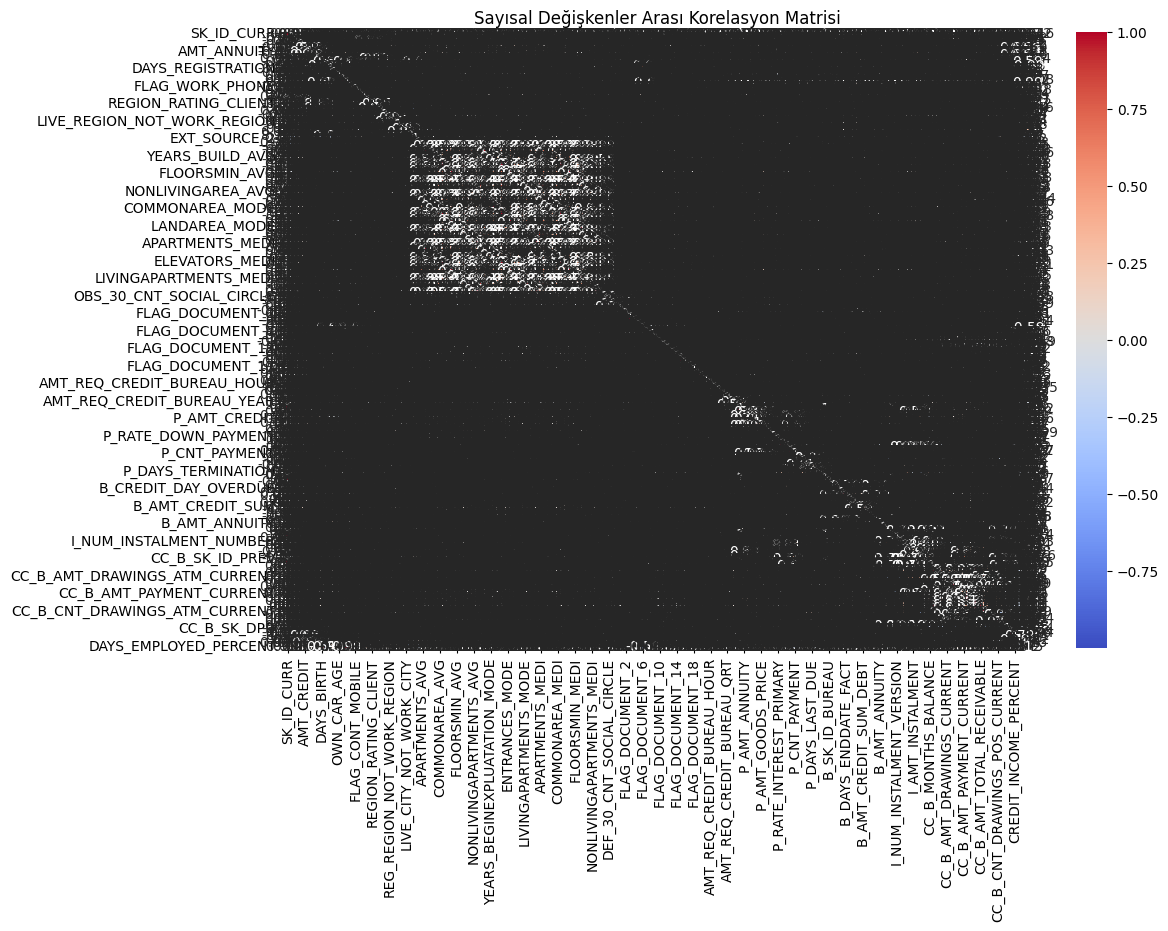


Korelasyonu 0.8'dan yüksek olan sayısal değişken çiftleri:
                        col1                   col2  correlation
0                 SK_ID_CURR           P_SK_ID_CURR     1.000000
129             B_SK_ID_CURR           I_SK_ID_CURR     1.000000
120             P_SK_ID_CURR        CC_B_SK_ID_CURR     1.000000
131             I_SK_ID_CURR        CC_B_SK_ID_CURR     1.000000
119             P_SK_ID_CURR           I_SK_ID_CURR     1.000000
..                       ...                    ...          ...
55      LIVINGAPARTMENTS_AVG         ELEVATORS_MEDI     0.809331
76           APARTMENTS_MODE         ELEVATORS_MEDI     0.808858
84            ELEVATORS_MODE  LIVINGAPARTMENTS_MODE     0.807601
34             ELEVATORS_AVG        APARTMENTS_MODE     0.806009
132  I_NUM_INSTALMENT_NUMBER        CC_B_SK_ID_PREV     0.801564

[151 rows x 3 columns]


In [105]:
# 1. Sayısal değişkenler arası korelasyon
df = data
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_corr = df[numeric_cols].corr()

# Korelasyon matrisi görselleştirme
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_corr, annot=True, cmap='coolwarm', center=0)
plt.title('Sayısal Değişkenler Arası Korelasyon Matrisi')
plt.show()

# Yüksek korelasyonlu sayısal değişken çiftlerini bulma
threshold = 0.8  # Eşik değeri isteğinize göre değiştirebilirsiniz
high_corr_pairs = []

for i in range(len(numeric_cols)):
    for j in range(i+1, len(numeric_cols)):
        corr = abs(numeric_corr.iloc[i, j])
        if corr > threshold:
            high_corr_pairs.append({
                'col1': numeric_cols[i],
                'col2': numeric_cols[j],
                'correlation': corr
            })

# Yüksek korelasyonlu çiftleri DataFrame'e çevirip görüntüleme
high_corr_df = pd.DataFrame(high_corr_pairs)
if len(high_corr_df) > 0:
    print(f"\nKorelasyonu {threshold}'dan yüksek olan sayısal değişken çiftleri:")
    print(high_corr_df.sort_values('correlation', ascending=False))
else:
    print(f"\nKorelasyonu {threshold}'dan yüksek sayısal değişken çifti bulunamadı.")

In [106]:
# 2. Kategorik değişkenler arası korelasyon (Cramer's V)
categorical_cols = df.select_dtypes(exclude=[np.number]).columns
categorical_pairs = []

for i in range(len(categorical_cols)):
    for j in range(i+1, len(categorical_cols)):
        col1, col2 = categorical_cols[i], categorical_cols[j]
        
        # Contingency table oluştur
        contingency = pd.crosstab(df[col1], df[col2])
        chi2, _, _, _ = chi2_contingency(contingency)
        
        # Cramer's V hesapla
        n = contingency.sum().sum()
        min_dim = min(contingency.shape) - 1
        if min_dim == 0:  # Eğer değişkenlerden biri tek değere sahipse
            cramer_v = 0
        else:
            cramer_v = np.sqrt(chi2 / (n * min_dim))
        
        if cramer_v > threshold:
            categorical_pairs.append({
                'col1': col1,
                'col2': col2,
                'cramer_v': cramer_v
            })

# Yüksek Cramer's V değerine sahip çiftleri görüntüle
cat_corr_df = pd.DataFrame(categorical_pairs)
if len(cat_corr_df) > 0:
    print(f"\nCramer's V değeri {threshold}'dan yüksek olan kategorik değişken çiftleri:")
    print(cat_corr_df.sort_values('cramer_v', ascending=False))
else:
    print(f"\nCramer's V değeri {threshold}'dan yüksek kategorik değişken çifti bulunamadı.")



Cramer's V değeri 0.8'dan yüksek kategorik değişken çifti bulunamadı.


In [109]:
# 3. Binary kategorik ve sayısal değişkenler arası korelasyon
binary_mixed_pairs = []

for cat_col in categorical_cols:
    # Sadece binary kategorik değişkenler için
    if df[cat_col].nunique() == 2:
        for num_col in numeric_cols:
            # Kategorik değişkeni 0-1 kodla ve Series'e çevir
            cat_coded = pd.Series(pd.Categorical(df[cat_col]).codes, index=df.index)
            correlation = abs(df[num_col].corr(cat_coded))
            
            if correlation > threshold:
                binary_mixed_pairs.append({
                    'categorical': cat_col,
                    'numeric': num_col,
                    'correlation': correlation
                })

# Yüksek korelasyonlu binary-sayısal çiftleri görüntüle
binary_corr_df = pd.DataFrame(binary_mixed_pairs)
if len(binary_corr_df) > 0:
    print(f"\nKorelasyonu {threshold}'dan yüksek olan binary-sayısal değişken çiftleri:")
    print(binary_corr_df.sort_values('correlation', ascending=False))
else:
    print(f"\nKorelasyonu {threshold}'dan yüksek binary-sayısal değişken çifti bulunamadı.")

/Users/mustafaaktas/anaconda3/envs/Federated-Learning-Comparative-Study/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/mustafaaktas/anaconda3/envs/Federated-Learning-Comparative-Study/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



Korelasyonu 0.8'dan yüksek binary-sayısal değişken çifti bulunamadı.


In [110]:
# 4. Her değişkenin kaç kez yüksek korelasyon gösterdiğini sayma
column_frequency = {}

# Sayısal değişken çiftleri için
for pair in high_corr_pairs:
    column_frequency[pair['col1']] = column_frequency.get(pair['col1'], 0) + 1
    column_frequency[pair['col2']] = column_frequency.get(pair['col2'], 0) + 1

# Kategorik değişken çiftleri için
for pair in categorical_pairs:
    column_frequency[pair['col1']] = column_frequency.get(pair['col1'], 0) + 1
    column_frequency[pair['col2']] = column_frequency.get(pair['col2'], 0) + 1

# Binary-sayısal çiftler için
for pair in binary_mixed_pairs:
    column_frequency[pair['categorical']] = column_frequency.get(pair['categorical'], 0) + 1
    column_frequency[pair['numeric']] = column_frequency.get(pair['numeric'], 0) + 1

# Sıklık sonuçlarını görüntüle
if column_frequency:
    print("\nDeğişkenlerin yüksek korelasyon gösterme sıklığı:")
    for col, freq in sorted(column_frequency.items(), key=lambda x: x[1], reverse=True):
        print(f"{col}: {freq} kez")
else:
    print("\nHiçbir değişken yüksek korelasyon göstermedi.")


Değişkenlerin yüksek korelasyon gösterme sıklığı:
APARTMENTS_AVG: 12 kez
LIVINGAREA_AVG: 12 kez
APARTMENTS_MODE: 12 kez
LIVINGAREA_MODE: 12 kez
APARTMENTS_MEDI: 12 kez
LIVINGAREA_MEDI: 12 kez
TOTALAREA_MODE: 12 kez
ELEVATORS_AVG: 11 kez
LIVINGAPARTMENTS_AVG: 11 kez
ELEVATORS_MEDI: 11 kez
LIVINGAPARTMENTS_MEDI: 11 kez
ELEVATORS_MODE: 10 kez
LIVINGAPARTMENTS_MODE: 10 kez
SK_ID_CURR: 4 kez
P_SK_ID_CURR: 4 kez
B_SK_ID_CURR: 4 kez
I_SK_ID_CURR: 4 kez
CC_B_SK_ID_CURR: 4 kez
CC_B_AMT_BALANCE: 4 kez
CC_B_AMT_INST_MIN_REGULARITY: 4 kez
CC_B_AMT_RECEIVABLE_PRINCIPAL: 4 kez
CC_B_AMT_RECIVABLE: 4 kez
CC_B_AMT_TOTAL_RECEIVABLE: 4 kez
P_AMT_GOODS_PRICE: 3 kez
DAYS_EMPLOYED: 2 kez
FLAG_EMP_PHONE: 2 kez
DAYS_EMPLOYED_PERCENT: 2 kez
BASEMENTAREA_AVG: 2 kez
BASEMENTAREA_MODE: 2 kez
BASEMENTAREA_MEDI: 2 kez
YEARS_BEGINEXPLUATATION_AVG: 2 kez
YEARS_BEGINEXPLUATATION_MODE: 2 kez
YEARS_BEGINEXPLUATATION_MEDI: 2 kez
YEARS_BUILD_AVG: 2 kez
YEARS_BUILD_MODE: 2 kez
YEARS_BUILD_MEDI: 2 kez
COMMONAREA_AVG: 2 kez

In [114]:
def drop_highly_correlated(df, threshold=0.8):
    """
    1. ID kolonlarını çıkar
    2. AVG/MODE/MEDI üçlüsünden MEDI'yi tut, diğerlerini çıkar
    3. Kalan yüksek korelasyonlu değişkenleri çıkar
    """
    print("Başlangıç sütun sayısı:", len(df.columns))
    
    # 1. ID kolonlarını çıkar
    id_columns = [col for col in df.columns if 'SK_ID' in col]
    df = df.drop(columns=id_columns)
    print(f"ID kolonları çıkarıldıktan sonra ({len(id_columns)} adet):", len(df.columns))
    
    # 2. AVG/MODE/MEDI üçlüsünden MEDI'yi tut
    # Önce bu pattern'e uyan kolonları bul
    stat_patterns = []
    for col in df.columns:
        # Base adını bul (örn: APARTMENTS, LIVINGAREA vs.)
        base_name = col.replace('_AVG', '').replace('_MODE', '').replace('_MEDI', '')
        if f"{base_name}_AVG" in df.columns and f"{base_name}_MODE" in df.columns and f"{base_name}_MEDI" in df.columns:
            if base_name not in stat_patterns:
                stat_patterns.append(base_name)
    
    # Her pattern için AVG ve MODE'u çıkar
    columns_to_drop = []
    for pattern in stat_patterns:
        columns_to_drop.extend([f"{pattern}_AVG", f"{pattern}_MODE"])
    
    df = df.drop(columns=columns_to_drop)
    print(f"AVG/MODE kolonları çıkarıldıktan sonra ({len(columns_to_drop)} adet):", len(df.columns))
    
    # 3. Kalan yüksek korelasyonlu değişkenleri çıkar
    # Sadece sayısal kolonlar üzerinde korelasyon hesapla
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    corr_matrix = df[numeric_cols].corr().abs()
    
    # Üst üçgeni al
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Yüksek korelasyonlu kolonları bul
    high_corr_cols = [column for column in upper.columns if any(upper[column] > threshold)]
    
    if high_corr_cols:
        print("\nKalan yüksek korelasyonlu değişken çiftleri:")
        for col in upper.columns:
            high_corr = upper[col][upper[col] > threshold].index.tolist()
            if high_corr:
                print(f"{col} ile yüksek korelasyonlu olanlar: {high_corr}")
                print(f"Korelasyon değerleri: {upper[col][upper[col] > threshold].values.tolist()}\n")
    
        # Her yüksek korelasyonlu çift için birini çıkar
        to_drop = []
        seen = set()
        
        for col in high_corr_cols:
            if col not in seen:
                correlated = upper[col][upper[col] > threshold].index.tolist()
                if correlated:
                    # Korelasyonlu değişkenlerden birini seç (ilkini çıkar)
                    to_drop.append(col)
                    seen.add(col)
                    seen.update(correlated)
        
        df = df.drop(columns=to_drop)
        print(f"\nKalan yüksek korelasyonlu kolonlar çıkarıldıktan sonra ({len(to_drop)} adet):", len(df.columns))
    else:
        print("\nKalan kolonlar arasında yüksek korelasyon bulunamadı.")
    
    # Çıkarılan tüm kolonların listesini tut
    all_dropped = id_columns + columns_to_drop + (to_drop if high_corr_cols else [])
    
    print("\nToplam çıkarılan sütun sayısı:", len(all_dropped))
    print("\nÇıkarılan sütunlar:")
    for col in all_dropped:
        print(col)
        
    return df, all_dropped

In [115]:
# Kullanımı:
df_cleaned, hig_corr_cols = drop_highly_correlated(df, threshold=0.9)

Başlangıç sütun sayısı: 192
ID kolonları çıkarıldıktan sonra (9 adet): 183
AVG/MODE kolonları çıkarıldıktan sonra (28 adet): 155

Kalan yüksek korelasyonlu değişken çiftleri:
AMT_GOODS_PRICE ile yüksek korelasyonlu olanlar: ['AMT_CREDIT']
Korelasyon değerleri: [0.9869683054221499]

FLAG_EMP_PHONE ile yüksek korelasyonlu olanlar: ['DAYS_EMPLOYED']
Korelasyon değerleri: [0.999755011444388]

REGION_RATING_CLIENT_W_CITY ile yüksek korelasyonlu olanlar: ['REGION_RATING_CLIENT']
Korelasyon değerleri: [0.9508422141646482]

LIVINGAPARTMENTS_MEDI ile yüksek korelasyonlu olanlar: ['APARTMENTS_MEDI']
Korelasyon değerleri: [0.9424851483864675]

LIVINGAREA_MEDI ile yüksek korelasyonlu olanlar: ['APARTMENTS_MEDI']
Korelasyon değerleri: [0.9159473447265859]

TOTALAREA_MODE ile yüksek korelasyonlu olanlar: ['LIVINGAREA_MEDI']
Korelasyon değerleri: [0.9193633193815423]

OBS_60_CNT_SOCIAL_CIRCLE ile yüksek korelasyonlu olanlar: ['OBS_30_CNT_SOCIAL_CIRCLE']
Korelasyon değerleri: [0.998489542510996]

P_AM

In [116]:
print("CV'si düşük olanlar:")
print(low_cv_columns)
print(low_var_categorical)
print("####################################")
print("CV'si düşük olanlar (binary):")
print(results[(2, 70)]['all_drops'])
print("####################################")
print("Correlation'ı yüksek olanlar:")
print(hig_corr_cols)

all_drop_cols = low_cv_columns + low_var_categorical + results[(2, 70)]['all_drops'] + hig_corr_cols

CV'si düşük olanlar:
['FLAG_MOBIL', 'FLAG_CONT_MOBILE', 'P_NFLAG_LAST_APPL_IN_DAY']
[]
####################################
CV'si düşük olanlar (binary):
['REG_REGION_NOT_LIVE_REGION', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_21', 'EMERGENCYSTATE_MODE', 'FLAG_MOBIL', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_4', 'FLAG_CONT_MOBILE', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_19']
####################################
Correlation'ı yüksek olanlar:
['SK_ID_CURR', 'P_SK_ID_PREV', 'P_SK_ID_CURR', 'B_SK_ID_CURR', 'B_SK_ID_BUREAU', 'I_SK_ID_PREV', 'I_SK_ID_CURR', 'CC_B_SK_ID_PREV', 'CC_B_SK_ID_CURR', 'APARTMENTS_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_AVG', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_AVG', 'YEARS_BUILD_MODE', 'COMMONAREA_AVG', 'COMMON

In [117]:
data_dropped = data.drop(all_drop_cols, axis=1)

In [118]:
data_dropped.shape

(307511, 114)

In [121]:
X = data_dropped.drop(['TARGET'], axis=1)
y = data_dropped['TARGET']

In [122]:
X.shape

(307511, 113)

In [123]:
y.shape

(307511,)

In [126]:
X.head()

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,NAME_TYPE_SUITE,NAME_INCOME_TYPE,...,CC_B_AMT_PAYMENT_CURRENT,CC_B_CNT_DRAWINGS_ATM_CURRENT,CC_B_CNT_DRAWINGS_CURRENT,CC_B_CNT_DRAWINGS_OTHER_CURRENT,CC_B_CNT_INSTALMENT_MATURE_CUM,CC_B_SK_DPD,CC_B_SK_DPD_DEF,CREDIT_INCOME_PERCENT,ANNUITY_INCOME_PERCENT,CREDIT_TERM
0,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,Unaccompanied,Working,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.007889,0.121978,0.060749
1,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,Family,State servant,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.790750,0.132217,0.027598
2,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,Unaccompanied,Working,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,0.100000,0.050000
3,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,Unaccompanied,Working,...,NaN,NaN,0.0,NaN,0.0,0.0,0.0,2.316167,0.219900,0.094941
4,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,Unaccompanied,Working,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.222222,0.179963,0.042623


In [128]:
for c in X.columns:
    print(c)

NAME_CONTRACT_TYPE
CODE_GENDER
FLAG_OWN_CAR
FLAG_OWN_REALTY
CNT_CHILDREN
AMT_INCOME_TOTAL
AMT_CREDIT
AMT_ANNUITY
NAME_TYPE_SUITE
NAME_INCOME_TYPE
NAME_EDUCATION_TYPE
NAME_FAMILY_STATUS
NAME_HOUSING_TYPE
REGION_POPULATION_RELATIVE
DAYS_BIRTH
DAYS_EMPLOYED
DAYS_REGISTRATION
DAYS_ID_PUBLISH
OWN_CAR_AGE
FLAG_WORK_PHONE
FLAG_PHONE
FLAG_EMAIL
OCCUPATION_TYPE
CNT_FAM_MEMBERS
REGION_RATING_CLIENT
WEEKDAY_APPR_PROCESS_START
HOUR_APPR_PROCESS_START
REG_REGION_NOT_WORK_REGION
LIVE_REGION_NOT_WORK_REGION
REG_CITY_NOT_LIVE_CITY
REG_CITY_NOT_WORK_CITY
LIVE_CITY_NOT_WORK_CITY
ORGANIZATION_TYPE
EXT_SOURCE_1
EXT_SOURCE_2
EXT_SOURCE_3
APARTMENTS_MEDI
BASEMENTAREA_MEDI
YEARS_BEGINEXPLUATATION_MEDI
YEARS_BUILD_MEDI
COMMONAREA_MEDI
ELEVATORS_MEDI
ENTRANCES_MEDI
FLOORSMAX_MEDI
FLOORSMIN_MEDI
LANDAREA_MEDI
NONLIVINGAPARTMENTS_MEDI
NONLIVINGAREA_MEDI
FONDKAPREMONT_MODE
HOUSETYPE_MODE
WALLSMATERIAL_MODE
OBS_30_CNT_SOCIAL_CIRCLE
DEF_30_CNT_SOCIAL_CIRCLE
DEF_60_CNT_SOCIAL_CIRCLE
DAYS_LAST_PHONE_CHANGE
FLAG_DOCUM